# Unità 5 — Rumore e decoerenza: primo modello bit-flip

In questo notebook introduciamo un primo modello di rumore sul canale quantistico. Il modello è semplificato: con probabilità `p` il canale applica un bit-flip, cioè un gate `X`, al qubit trasmesso da Alice a Bob.

## Setup e import

In [ ]:
from pathlib import Path
import sys

current_path = Path.cwd()

if (current_path / "src" / "noise.py").exists():
    project_root = current_path
elif (current_path.parent / "src" / "noise.py").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Non trovo la cartella src del progetto.")

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("Project root:", project_root)

Project root: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from noise import (
    run_bb84_round_with_bit_flip_noise,
    run_bb84_protocol_with_bit_flip_noise,
    run_bb84_round_with_amplitude_damping,
    run_bb84_protocol_with_amplitude_damping,
)
from bb84 import sift_keys, compute_qber
from metrics import summarize_qkd_results

## Interpretazione del rumore bit-flip

Il bit-flip è un modello semplice di errore. Nel circuito viene rappresentato con il gate `X`: con probabilità `noise_probability` il gate viene applicato al qubit, mentre con probabilità `1 - noise_probability` il qubit non viene alterato. La variabile `noise_applied` indica se in quello specifico round il bit-flip è stato applicato.

Il bit-flip non produce lo stesso effetto sulle basi `Z` e `X`. In base `Z` inverte il bit, mentre in base `X` può non modificare il risultato della misura, perché `X|+⟩ = |+⟩` e `X|-⟩ = -|-⟩`, dove il segno globale non cambia le probabilità di misura.

## Singolo round con rumore

In [ ]:
round_z = run_bb84_round_with_bit_flip_noise(
    alice_bit=1,
    alice_basis="Z",
    bob_basis="Z",
    noise_probability=1.0,
    seed=10,
)

print("Round in base Z con bit-flip sempre applicato:")
print(round_z)

Round in base Z con bit-flip sempre applicato:
{'alice_bit': 1, 'alice_basis': 'Z', 'bob_basis': 'Z', 'bob_bit': 0, 'noise_applied': True}


Con probabilità di rumore pari a `1.0`, il bit-flip viene sempre applicato. In base `Z` ci si aspetta un'inversione del bit misurato da Bob.

In [ ]:
round_x = run_bb84_round_with_bit_flip_noise(
    alice_bit=0,
    alice_basis="X",
    bob_basis="X",
    noise_probability=1.0,
    seed=10,
)

print("Round in base X con bit-flip sempre applicato:")
print(round_x)

Round in base X con bit-flip sempre applicato:
{'alice_bit': 0, 'alice_basis': 'X', 'bob_basis': 'X', 'bob_bit': 0, 'noise_applied': True}


In base `X`, il gate `X` non produce necessariamente un errore osservabile nella misura. Per questo il rumore bit-flip ha un effetto diverso a seconda della base usata.

## Protocollo multi-round con rumore fissato

In [ ]:
n_rounds = 500
noise_probability = 0.2
qber_threshold = 0.11
seed = 123

results_noise = run_bb84_protocol_with_bit_flip_noise(
    n_rounds=n_rounds,
    noise_probability=noise_probability,
    seed=seed,
)

alice_key_noise, bob_key_noise = sift_keys(results_noise)
qber_noise = compute_qber(alice_key_noise, bob_key_noise)

summary_noise = summarize_qkd_results(
    protocol_name="BB84 bit-flip noise",
    results=results_noise,
    alice_key=alice_key_noise,
    bob_key=bob_key_noise,
    qber=qber_noise,
    qber_threshold=qber_threshold,
)

print("Riassunto BB84 con rumore bit-flip:")
print(summary_noise)

Riassunto BB84 con rumore bit-flip:
{'protocol': 'BB84 bit-flip noise', 'n_rounds': 500, 'kept_rounds': 266, 'discarded_rounds': 234, 'sifted_key_length': 266, 'sifted_key_rate': 0.532, 'qber': 0.10150375939849623, 'qber_threshold': 0.11, 'accepted': True}


## Tabella dei primi round

In [ ]:
df_noise = pd.DataFrame(results_noise)
df_noise.head(10)

,round,alice_bit,alice_basis,bob_basis,bob_bit,keep,noise_applied
0,1,0,X,Z,1,False,False
1,2,1,X,X,1,True,False
2,3,1,X,Z,0,False,False
3,4,0,X,Z,1,False,True
4,5,1,X,Z,1,False,False
5,6,0,X,Z,0,False,False
6,7,0,Z,X,0,False,False
7,8,0,X,Z,0,False,False
8,9,0,X,X,0,True,False
9,10,0,X,Z,0,False,True


La colonna `noise_applied` indica se il bit-flip è stato applicato nel round specifico. La colonna `keep` indica invece se Alice e Bob hanno usato la stessa base e quindi se il round entra nella chiave sifted.

## QBER al variare della probabilità di rumore

Ora ripetiamo la simulazione per diversi valori di `noise_probability`. In questo modo osserviamo come cambiano QBER, lunghezza della chiave sifted e decisione di accettazione della chiave.

In [ ]:
noise_probabilities = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]
n_rounds_sweep = 1000
qber_threshold_sweep = 0.11
sweep_results = []

for i in range(len(noise_probabilities)):
    probability = noise_probabilities[i]
    results = run_bb84_protocol_with_bit_flip_noise(
        n_rounds=n_rounds_sweep,
        noise_probability=probability,
        seed=200 + i,
    )
    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)
    summary = summarize_qkd_results(
        protocol_name="BB84 bit-flip noise",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_sweep,
    )
    summary["noise_probability"] = probability
    sweep_results.append(summary)

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,protocol,n_rounds,kept_rounds,discarded_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,noise_probability
0,BB84 bit-flip noise,1000,479,521,479,0.479,0.000000,0.11,True,0.00
1,BB84 bit-flip noise,1000,511,489,511,0.511,0.031311,0.11,True,0.05
2,BB84 bit-flip noise,1000,500,500,500,0.500,0.050000,0.11,True,0.10
3,BB84 bit-flip noise,1000,515,485,515,0.515,0.075728,0.11,True,0.20
4,BB84 bit-flip noise,1000,497,503,497,0.497,0.130785,0.11,False,0.30
5,BB84 bit-flip noise,1000,448,552,448,0.448,0.176339,0.11,False,0.40


## Grafico QBER vs rumore

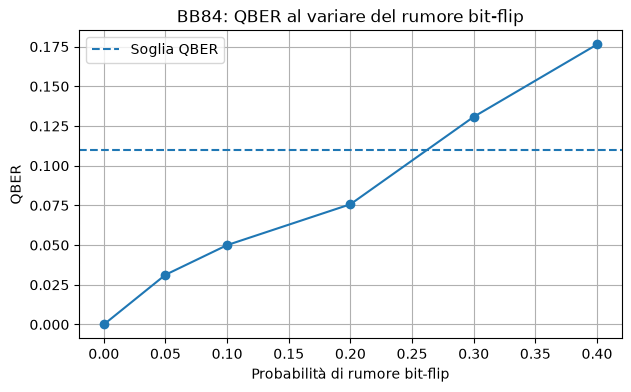

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["noise_probability"],
    sweep_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di rumore bit-flip")
plt.ylabel("QBER")
plt.title("BB84: QBER al variare del rumore bit-flip")
plt.grid(True)
plt.legend()
plt.show()

## Grafico sifted key rate vs rumore

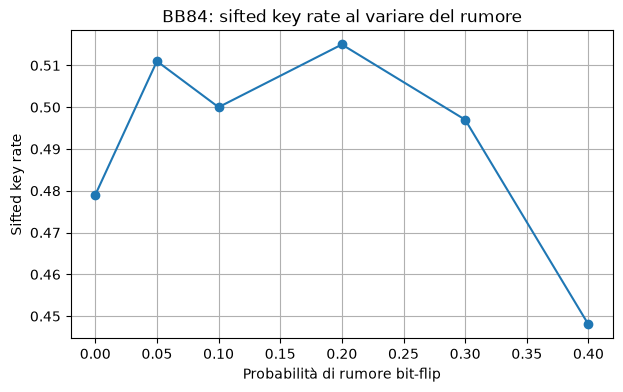

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["noise_probability"],
    sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di rumore bit-flip")
plt.ylabel("Sifted key rate")
plt.title("BB84: sifted key rate al variare del rumore")
plt.grid(True)
plt.show()

## Commento interpretativo

Aumentando la probabilità di rumore, il QBER tende ad aumentare. Il `sifted_key_rate` dipende soprattutto dal confronto delle basi scelte da Alice e Bob, quindi non cambia necessariamente molto con questo modello. La soglia QBER permette di decidere quando una chiave è accettata o rifiutata. Il modello bit-flip è didattico e non descrive tutti i possibili rumori fisici; nel blocco successivo si potrà introdurre amplitude damping, più vicino a un modello di dissipazione e decoerenza.

## BB84 con amplitude damping

L'amplitude damping è un modello di rumore più fisico del bit-flip, perché rappresenta una perdita di eccitazione dal livello `|1⟩` verso il livello `|0⟩`. Nel circuito il canale rumoroso è rappresentato tramite un'istruzione identity `id`, alla quale Qiskit Aer associa il noise model. Questo modello è asimmetrico: `|0⟩` è stabile, mentre `|1⟩` può decadere verso `|0⟩`. Per questo è utile come primo modello di dissipazione e decoerenza.

In [ ]:
round_damping_z = run_bb84_round_with_amplitude_damping(
    alice_bit=1,
    alice_basis="Z",
    bob_basis="Z",
    damping_probability=1.0,
    seed=10,
)

print(round_damping_z)

Con `damping_probability = 1.0` e base `Z`, lo stato `|1⟩` tende a decadere verso `|0⟩`. Quindi Bob può ottenere `0` anche se Alice ha inviato `1`.

In [ ]:
round_damping_zero = run_bb84_round_with_amplitude_damping(
    alice_bit=0,
    alice_basis="Z",
    bob_basis="Z",
    damping_probability=1.0,
    seed=10,
)

print(round_damping_zero)

Se Alice invia `|0⟩`, l'amplitude damping non produce decadimento verso un livello più basso. In questo senso lo stato `|0⟩` è stabile rispetto a questo modello.

## Protocollo multi-round con amplitude damping fissato

In [ ]:
n_rounds_damping = 500
damping_probability = 0.2
qber_threshold_damping = 0.11
seed_damping = 321

results_damping = run_bb84_protocol_with_amplitude_damping(
    n_rounds=n_rounds_damping,
    damping_probability=damping_probability,
    seed=seed_damping,
)

alice_key_damping, bob_key_damping = sift_keys(results_damping)
qber_damping = compute_qber(alice_key_damping, bob_key_damping)

summary_damping = summarize_qkd_results(
    protocol_name="BB84 amplitude damping",
    results=results_damping,
    alice_key=alice_key_damping,
    bob_key=bob_key_damping,
    qber=qber_damping,
    qber_threshold=qber_threshold_damping,
)

print(summary_damping)

## Tabella dei primi round amplitude damping

In [ ]:
df_damping = pd.DataFrame(results_damping)
df_damping.head(10)

La colonna `damping_probability` non indica se il decadimento è avvenuto in quel singolo round. Indica invece il parametro del noise model usato dal simulatore per quel round.

## QBER al variare dell'amplitude damping

Ripetiamo la simulazione per diversi valori di `damping_probability`. In questo modo possiamo osservare come il decadimento influenzi il QBER e le metriche della chiave sifted.

In [ ]:
damping_probabilities = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]
n_rounds_damping_sweep = 1000
qber_threshold_damping_sweep = 0.11
damping_sweep_results = []

for i in range(len(damping_probabilities)):
    probability = damping_probabilities[i]

    results = run_bb84_protocol_with_amplitude_damping(
        n_rounds=n_rounds_damping_sweep,
        damping_probability=probability,
        seed=500 + i,
    )

    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)

    summary = summarize_qkd_results(
        protocol_name="BB84 amplitude damping",
        results=results,
        alice_key=alice_key,
        bob_key=bob_key,
        qber=qber,
        qber_threshold=qber_threshold_damping_sweep,
    )

    summary["damping_probability"] = probability
    damping_sweep_results.append(summary)

damping_sweep_df = pd.DataFrame(damping_sweep_results)
damping_sweep_df

## Grafico QBER vs amplitude damping

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    damping_sweep_df["damping_probability"],
    damping_sweep_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_damping_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di amplitude damping")
plt.ylabel("QBER")
plt.title("QBER al variare dell'amplitude damping")
plt.grid(True)
plt.legend()
plt.show()

## Grafico sifted key rate vs amplitude damping

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    damping_sweep_df["damping_probability"],
    damping_sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di amplitude damping")
plt.ylabel("Sifted key rate")
plt.title("Sifted key rate al variare dell'amplitude damping")
plt.grid(True)
plt.show()

## Confronto tra bit-flip noise e amplitude damping

In [ ]:
comparison_noise_rows = []

for i in range(len(sweep_df)):
    row = {
        "noise_model": "bit-flip",
        "probability": sweep_df.loc[i, "noise_probability"],
        "qber": sweep_df.loc[i, "qber"],
        "sifted_key_rate": sweep_df.loc[i, "sifted_key_rate"],
        "accepted": sweep_df.loc[i, "accepted"],
    }
    comparison_noise_rows.append(row)

for i in range(len(damping_sweep_df)):
    row = {
        "noise_model": "amplitude damping",
        "probability": damping_sweep_df.loc[i, "damping_probability"],
        "qber": damping_sweep_df.loc[i, "qber"],
        "sifted_key_rate": damping_sweep_df.loc[i, "sifted_key_rate"],
        "accepted": damping_sweep_df.loc[i, "accepted"],
    }
    comparison_noise_rows.append(row)

noise_comparison_df = pd.DataFrame(comparison_noise_rows)
noise_comparison_df

## Grafico confronto QBER

In [ ]:
bit_flip_df = noise_comparison_df[noise_comparison_df["noise_model"] == "bit-flip"]
amplitude_df = noise_comparison_df[noise_comparison_df["noise_model"] == "amplitude damping"]

plt.figure(figsize=(7, 4))
plt.plot(
    bit_flip_df["probability"],
    bit_flip_df["qber"],
    marker="o",
    label="bit-flip",
)
plt.plot(
    amplitude_df["probability"],
    amplitude_df["qber"],
    marker="o",
    label="amplitude damping",
)
plt.axhline(
    y=qber_threshold_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità del rumore")
plt.ylabel("QBER")
plt.title("Confronto QBER tra modelli di rumore")
plt.grid(True)
plt.legend()
plt.show()

## Grafico confronto sifted key rate

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    bit_flip_df["probability"],
    bit_flip_df["sifted_key_rate"],
    marker="o",
    label="bit-flip",
)
plt.plot(
    amplitude_df["probability"],
    amplitude_df["sifted_key_rate"],
    marker="o",
    label="amplitude damping",
)
plt.xlabel("Probabilità del rumore")
plt.ylabel("Sifted key rate")
plt.title("Confronto sifted key rate tra modelli di rumore")
plt.grid(True)
plt.legend()
plt.show()

## Commento interpretativo finale

Bit-flip e amplitude damping sono due modelli diversi. Il bit-flip applica una inversione discreta tramite il gate `X`, mentre l'amplitude damping descrive una perdita di eccitazione da `|1⟩` verso `|0⟩`. Entrambi possono aumentare il QBER. Il `sifted_key_rate` resta invece legato soprattutto alla probabilità che Alice e Bob scelgano la stessa base. L'amplitude damping è più utile per collegare il progetto al tema della dissipazione e della decoerenza. Una modellazione ancora più realistica potrebbe collegare `damping_probability` a distanza, attenuazione o tempo di propagazione.

## Salvataggio dei risultati

In [ ]:
from pathlib import Path

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Cartelle dei risultati pronte.")

Cartelle dei risultati pronte.


In [ ]:
sweep_table_path = tables_dir / "bb84_bit_flip_noise_sweep.csv"
sweep_df.to_csv(sweep_table_path, index=False)

damping_table_path = tables_dir / "bb84_amplitude_damping_sweep.csv"
damping_sweep_df.to_csv(damping_table_path, index=False)

comparison_table_path = tables_dir / "bb84_noise_model_comparison.csv"
noise_comparison_df.to_csv(comparison_table_path, index=False)

print(f"Tabella bit-flip salvata in: {sweep_table_path}")
print(f"Tabella amplitude damping salvata in: {damping_table_path}")
print(f"Tabella confronto rumore salvata in: {comparison_table_path}")

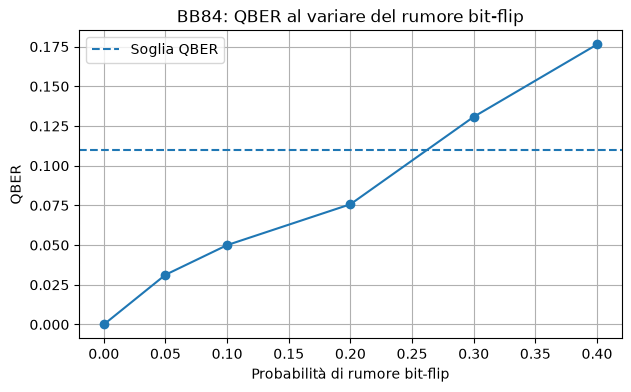

Grafico QBER salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_bit_flip_qber_vs_noise.png


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["noise_probability"],
    sweep_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di rumore bit-flip")
plt.ylabel("QBER")
plt.title("BB84: QBER al variare del rumore bit-flip")
plt.grid(True)
plt.legend()

qber_figure_path = figures_dir / "bb84_bit_flip_qber_vs_noise.png"
plt.savefig(qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER salvato in: {qber_figure_path}")

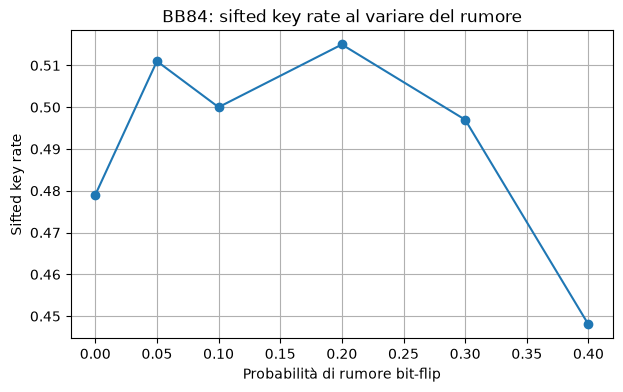

Grafico key rate salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_bit_flip_key_rate_vs_noise.png


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["noise_probability"],
    sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di rumore bit-flip")
plt.ylabel("Sifted key rate")
plt.title("BB84: sifted key rate al variare del rumore")
plt.grid(True)

key_rate_figure_path = figures_dir / "bb84_bit_flip_key_rate_vs_noise.png"
plt.savefig(key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico key rate salvato in: {key_rate_figure_path}")

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    damping_sweep_df["damping_probability"],
    damping_sweep_df["qber"],
    marker="o",
)
plt.axhline(
    y=qber_threshold_damping_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di amplitude damping")
plt.ylabel("QBER")
plt.title("QBER al variare dell'amplitude damping")
plt.grid(True)
plt.legend()

damping_qber_figure_path = figures_dir / "bb84_amplitude_damping_qber_vs_probability.png"
plt.savefig(damping_qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER amplitude damping salvato in: {damping_qber_figure_path}")

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    damping_sweep_df["damping_probability"],
    damping_sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di amplitude damping")
plt.ylabel("Sifted key rate")
plt.title("Sifted key rate al variare dell'amplitude damping")
plt.grid(True)

damping_key_rate_figure_path = figures_dir / "bb84_amplitude_damping_key_rate_vs_probability.png"
plt.savefig(damping_key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico key rate amplitude damping salvato in: {damping_key_rate_figure_path}")

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    bit_flip_df["probability"],
    bit_flip_df["qber"],
    marker="o",
    label="bit-flip",
)
plt.plot(
    amplitude_df["probability"],
    amplitude_df["qber"],
    marker="o",
    label="amplitude damping",
)
plt.axhline(
    y=qber_threshold_sweep,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità del rumore")
plt.ylabel("QBER")
plt.title("Confronto QBER tra modelli di rumore")
plt.grid(True)
plt.legend()

comparison_qber_figure_path = figures_dir / "bb84_noise_models_qber_comparison.png"
plt.savefig(comparison_qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico confronto QBER salvato in: {comparison_qber_figure_path}")

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(
    bit_flip_df["probability"],
    bit_flip_df["sifted_key_rate"],
    marker="o",
    label="bit-flip",
)
plt.plot(
    amplitude_df["probability"],
    amplitude_df["sifted_key_rate"],
    marker="o",
    label="amplitude damping",
)
plt.xlabel("Probabilità del rumore")
plt.ylabel("Sifted key rate")
plt.title("Confronto sifted key rate tra modelli di rumore")
plt.grid(True)
plt.legend()

comparison_key_rate_figure_path = figures_dir / "bb84_noise_models_key_rate_comparison.png"
plt.savefig(comparison_key_rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico confronto key rate salvato in: {comparison_key_rate_figure_path}")